<a href="https://colab.research.google.com/github/nekrochan/aruco-lab/blob/main/Lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AR на python

# Шаг 1

***Задание***

*На черно-белом изображении поставлены непересекающиеся, несоприкасающиеся и целые круги и квадраты заданного размера. Посчитайте число целых кругов и квадратов, не используя библиотеку cv2 или подобную.*

Создание изображения:

Фигура 1: circle, размер=36, центр=(223, 226)
Фигура 2: circle, размер=44, центр=(167, 328)
Фигура 3: square, размер=55, центр=(175, 265)
Фигура 4: circle, размер=33, центр=(369, 197)
Фигура 5: circle, размер=34, центр=(225, 187)
Фигура 6: square, размер=57, центр=(283, 336)
Фигура 7: square, размер=39, центр=(149, 178)
Фигура 8: square, размер=54, центр=(313, 222)


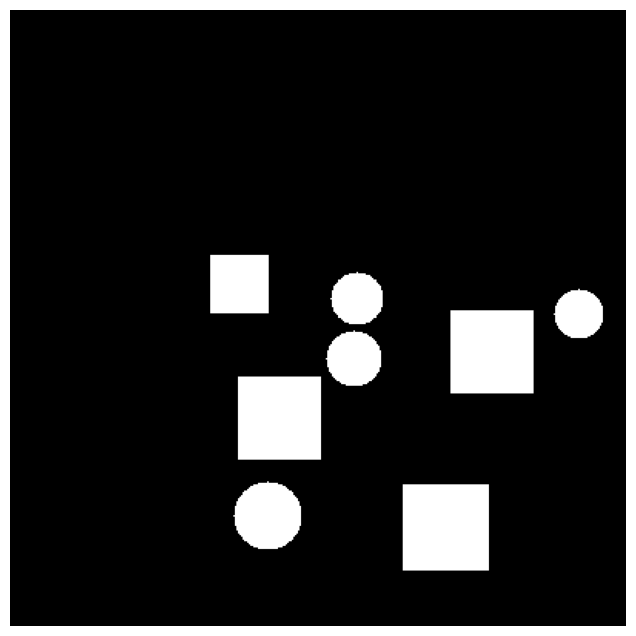

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint, choice

# ============================================================
# 1. Параметры изображения и фигур
# ============================================================
WIDTH = 400
HEIGHT = 400
MIN_SIZE = 20
MAX_SIZE = 60
NUM_SHAPES = 8
MAX_ATTEMPTS = 5000

# ============================================================
# 2. Создание пустого черного холста
# ============================================================
canvas = np.full((HEIGHT, WIDTH), 0, dtype=np.uint8)  # Изменено: 255 -> 0

# ============================================================
# 3. Функции для рисования (чистый NumPy)
# ============================================================
def draw_square(img, center_x, center_y, size):
    """Рисует белый квадрат на изображении."""
    half = size // 2
    x1 = center_x - half
    y1 = center_y - half
    x2 = center_x + half
    y2 = center_y + half

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img.shape[1], x2)
    y2 = min(img.shape[0], y2)

    img[y1:y2, x1:x2] = 255  # Изменено: 0 -> 255
    return img

def draw_circle(img, center_x, center_y, diameter):
    """Рисует белый круг на изображении."""
    radius = diameter // 2
    x1 = center_x - radius
    y1 = center_y - radius
    x2 = center_x + radius
    y2 = center_y + radius

    x1_clip = max(0, x1)
    y1_clip = max(0, y1)
    x2_clip = min(img.shape[1], x2)
    y2_clip = min(img.shape[0], y2)

    Y, X = np.ogrid[y1_clip:y2_clip, x1_clip:x2_clip]
    dist = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    mask = dist <= radius
    img[y1_clip:y2_clip, x1_clip:x2_clip][mask] = 255  # Изменено: 0 -> 255

    return img

def get_min_distance(size1, size2):
    """
    Вычисляет минимальное допустимое расстояние между
    центрами двух фигур по каждой оси,
    чтобы их ограничивающие квадраты не соприкасались.
    """
    half1 = size1 / 2
    half2 = size2 / 2
    return half1 + half2 + 1

# ============================================================
# 4. Логика размещения
# ============================================================
placed_shapes = []

for i in range(NUM_SHAPES):
    placed = False
    for attempt in range(MAX_ATTEMPTS):
        shape_type = choice(['square', 'circle'])
        current_size = randint(MIN_SIZE, MAX_SIZE)

        margin = current_size // 2
        cx = randint(margin, WIDTH - margin - 1)
        cy = randint(margin, HEIGHT - margin - 1)

        # Проверка пересечения
        overlap = False
        for s in placed_shapes:
            min_dist = get_min_distance(current_size, s['size'])
            if abs(cx - s['x']) < min_dist and abs(cy - s['y']) < min_dist:
                overlap = True
                break

        if not overlap:
            if shape_type == 'square':
                draw_square(canvas, cx, cy, current_size)
            else:
                draw_circle(canvas, cx, cy, current_size)

            placed_shapes.append({
                'type': shape_type,
                'x': cx,
                'y': cy,
                'size': current_size
            })
            placed = True
            print(f"Фигура {i+1}: {shape_type}, размер={current_size}, центр=({cx}, {cy})")
            break

    if not placed:
        print(f"ВНИМАНИЕ: Не удалось разместить фигуру {i+1} за {MAX_ATTEMPTS} попыток.")

# ============================================================
# 5. Визуализация результата
# ============================================================
plt.figure(figsize=(8, 8))
plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Подсчет фигур:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# -----------------------------------------------------------------------------
# ШАГ 1: Загрузка и подготовка изображения
# -----------------------------------------------------------------------------

# Имя файла, который должен лежать в текущей директории Colab
filename = 'figures.png'

try:
    # Читаем изображение с помощью matplotlib.
    # Результат будет массивом numpy размерности (H, W, C) или (H, W) для ч/б.
    img_raw = plt.imread(filename)

    # Если изображение цветное (3 канала) или с альфа-каналом (4 канала),
    # берем только первый канал, так как по условию оно Ч/Б.
    if len(img_raw.shape) > 2:
        img_gray = img_raw[:, :, 0]
    else:
        img_gray = img_raw

    # Приводим к типу uint8 для удобства работы с пикселями (0-255)
    # matplotlib может прочитать float в диапазоне 0.0-1.0, поэтому умножаем если нужно
    if img_gray.max() <= 1.0:
        img_bin = (img_gray * 255).astype(np.uint8)
    else:
        img_bin = img_gray.astype(np.uint8)

    # Пороговая обработка: гарантируем, что фон строго 0, а фигуры строго 1 (или 255)
    # Все, что больше 127, считаем белым (фигурой), остальное черным.
    img_binary = (img_bin > 127).astype(np.uint8)

    print(f"Изображение загружено\n")


except FileNotFoundError:
    print(f"Ошибка: Файл '{filename}' не найден\n")
    # Создадим заглушку, чтобы код ниже не падал с ошибкой синтаксиса,
    # но работать не будет.
    img_binary = np.zeros((100, 100), dtype=np.uint8)

# -----------------------------------------------------------------------------
# ШАГ 1.5: Обрезка белой рамки
# -----------------------------------------------------------------------------

def remove_white_border(img):
    """
    Удаляет белую рамку вокруг изображения.
    Фон гарантированно черный (0), рамка белая (1).
    Габариты рамки неизвестны.
    """
    height, width = img.shape

    # Находим все белые пиксели на границах изображения
    border_pixels = set()

    # Верхняя граница
    for x in range(width):
        if img[0, x] == 1:
            border_pixels.add((0, x))

    # Нижняя граница
    for x in range(width):
        if img[height-1, x] == 1:
            border_pixels.add((height-1, x))

    # Левая граница
    for y in range(height):
        if img[y, 0] == 1:
            border_pixels.add((y, 0))

    # Правая граница
    for y in range(height):
        if img[y, width-1] == 1:
            border_pixels.add((y, width-1))

    # Если нет белых пикселей на границе, рамки нет
    if not border_pixels:
        return img

    # Используем BFS для поиска всех пикселей, связанных с границей
    # (это и будет вся рамка, даже если она прерывистая)
    visited_border = np.zeros_like(img, dtype=bool)
    queue = deque(list(border_pixels))

    for y, x in border_pixels:
        visited_border[y, x] = True

    # Направления для 4-связности
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue:
        y, x = queue.popleft()

        for dy, dx in directions:
            ny, nx = y + dy, x + dx

            # Проверка границ
            if 0 <= ny < height and 0 <= nx < width:
                # Если пиксель белый и не посещен
                if img[ny, nx] == 1 and not visited_border[ny, nx]:
                    visited_border[ny, nx] = True
                    queue.append((ny, nx))

    # Находим минимальный прямоугольник, содержащий все НЕ рамки
    # (то есть все черные пиксели и белые фигуры внутри)
    non_border_pixels = np.where(visited_border == False)

    if len(non_border_pixels[0]) == 0:
        # Если все пиксели - рамка (маловероятно), возвращаем пустое изображение
        return np.zeros((1, 1), dtype=img.dtype)

    min_y = np.min(non_border_pixels[0])
    max_y = np.max(non_border_pixels[0])
    min_x = np.min(non_border_pixels[1])
    max_x = np.max(non_border_pixels[1])

    # Обрезаем изображение
    cropped_img = img[min_y:max_y+1, min_x:max_x+1]

    return cropped_img

# Применяем обрезку рамки
img_binary = remove_white_border(img_binary)

# -----------------------------------------------------------------------------
# ШАГ 2: Поиск связных компонент (алгоритм Flood Fill / BFS)
# -----------------------------------------------------------------------------

height, width = img_binary.shape
visited = np.zeros_like(img_binary, dtype=bool)  # Массив посещенных пикселей
components = []  # Список для хранения координат каждой найденной фигуры

# Направления для поиска соседей (4-связность: вверх, вниз, влево, вправо)
# Можно использовать 8-связность, но для квадратных/круглых фигур 4-связности обычно достаточно,
# если фигуры толстые. Для надежности возьмем 4 направления.
directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

for y in range(height):
    for x in range(width):
        # Если пиксель белый (часть фигуры) и мы его еще не посетили
        if img_binary[y, x] == 1 and not visited[y, x]:

            # Начинаем поиск новой компоненты связности
            current_component = []
            queue = deque()
            queue.append((y, x))
            visited[y, x] = True

            while queue:
                cy, cx = queue.popleft()
                current_component.append((cy, cx))

                # Проверяем 4 соседних пикселя
                for dy, dx in directions:
                    ny, nx = cy + dy, cx + dx

                    # Проверка выхода за границы изображения
                    if 0 <= ny < height and 0 <= nx < width:
                        # Если сосед белый и не посещен
                        if img_binary[ny, nx] == 1 and not visited[ny, nx]:
                            visited[ny, nx] = True
                            queue.append((ny, nx))

            # Добавляем найденную группу пикселей в общий список
            # Фильтр по размеру: каждая фигура >= 20 пикселей (по условию)
            if len(current_component) >= 20:
                components.append(current_component)

print(f"Найдено фигур: {len(components)} \n")

# -----------------------------------------------------------------------------
# ШАГ 3: Классификация фигур (Круг vs Квадрат)
# -----------------------------------------------------------------------------

circles_count = 0
squares_count = 0

# Для визуализации результатов (опционально, можно отключить)
debug_img = np.zeros_like(img_binary, dtype=np.uint8)

for comp in components:
    # Преобразуем список координат в numpy массив для удобных вычислений
    coords = np.array(comp)
    ys = coords[:, 0]
    xs = coords[:, 1]

    # 1. Вычисляем площадь фигуры (просто количество пикселей)
    area = len(comp)

    # 2. Находим ограничивающий прямоугольник (Bounding Box)
    min_y, max_y = np.min(ys), np.max(ys)
    min_x, max_x = np.min(xs), np.max(xs)

    # Ширина и высота прямоугольника
    box_h = max_y - min_y + 1
    box_w = max_x - min_x + 1
    box_area = box_h * box_w

    # 3. Критерий формы: Коэффициент заполнения (Extent)
    # Extent = Area_Figure / Area_BoundingBox
    # Для идеального квадрата Extent ~= 1.0
    # Для идеального круга Extent = pi/4 ~= 0.785

    if box_area == 0: continue # Защита от деления на ноль

    extent = area / box_area

    # Эвристическое правило разделения:
    # Если коэффициент заполнения > 0.9, считаем квадратом.
    # Если коэффициент заполнения < 0.9, считаем кругом.
    # Порог 0.9 выбран с запасом, так как цифровые круги имеют "лесенку",
    # но их заполнение все равно значительно меньше, чем у квадрата.

    if extent > 0.9:
        shape_type = "Square"
        squares_count += 1
        color_val = 200 # Серый для квадратов на отладочном изображении
    else:
        shape_type = "Circle"
        circles_count += 1
        color_val = 100 # Темно-серый для кругов

    # (Опционально) Рисуем найденные фигуры разными оттенками для проверки
    for y, x in comp:
        debug_img[y, x] = color_val

# -----------------------------------------------------------------------------
# ШАГ 4: Вывод результатов
# -----------------------------------------------------------------------------

print(f"Количество кругов: {circles_count}")
print(f"Количество квадратов: {squares_count}")


Изображение загружено

Найдено фигур: 8 

Количество кругов: 4
Количество квадратов: 4


# Шаг 2

***Задание***

*Выполните п.1 для цветного изображения, считая, что круги и квадраты имеют заданный цвет.*

Генерация изображения:

Фигура 1: circle, размер=39, центр=(50, 34), цвет=(255, 255, 0)
Фигура 2: square, размер=37, центр=(24, 360), цвет=(255, 255, 0)
Фигура 3: square, размер=38, центр=(296, 363), цвет=(255, 0, 0)
Фигура 4: circle, размер=67, центр=(200, 105), цвет=(255, 255, 0)
Фигура 5: circle, размер=23, центр=(201, 211), цвет=(255, 0, 255)
Фигура 6: square, размер=28, центр=(256, 29), цвет=(255, 255, 0)
Фигура 7: circle, размер=27, центр=(46, 246), цвет=(255, 255, 0)
Фигура 8: square, размер=61, центр=(117, 143), цвет=(255, 255, 0)
Фигура 9: circle, размер=22, центр=(99, 226), цвет=(255, 255, 0)
Фигура 10: square, размер=71, центр=(153, 219), цвет=(255, 0, 0)
Фигура 11: circle, размер=47, центр=(66, 308), цвет=(255, 0, 0)
Фигура 12: circle, размер=65, центр=(353, 329), цвет=(255, 0, 255)
Фигура 13: square, размер=39, центр=(319, 155), цвет=(255, 0, 255)
Фигура 14: circle, размер=26, центр=(296, 238), цвет=(255, 0, 255)
Фигура 15: square, размер=55, центр=(224, 320), цвет=(255, 0, 255)


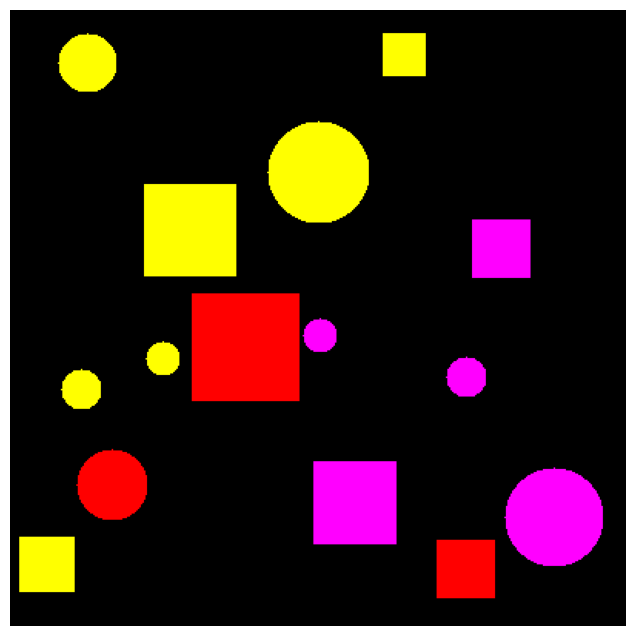

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint, choice

# ============================================================
# 1. Параметры изображения и фигур
# ============================================================
WIDTH = 400
HEIGHT = 400
MIN_SIZE = 20
MAX_SIZE = 80
NUM_SHAPES = 15
MAX_ATTEMPTS = 5000

# ============================================================
# 2. Создание пустого черного холста (RGB)
# ============================================================
canvas = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)  # Изменено: 3 канала для RGB

# ============================================================
# 3. Функции для рисования (чистый NumPy)
# ============================================================
def get_random_color():
    """Возвращает случайный цвет из заданных: желтый, маджента, красный"""
    colors = [
        (255, 255, 0),  # Желтый
        (255, 0, 255),  # Маджента
        (255, 0, 0)     # Красный
    ]
    return choice(colors)

def draw_square(img, center_x, center_y, size, color):
    """Рисует квадрат заданного цвета на изображении."""
    half = size // 2
    x1 = center_x - half
    y1 = center_y - half
    x2 = center_x + half
    y2 = center_y + half

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img.shape[1], x2)
    y2 = min(img.shape[0], y2)

    img[y1:y2, x1:x2] = color
    return img

def draw_circle(img, center_x, center_y, diameter, color):
    """Рисует круг заданного цвета на изображении."""
    radius = diameter // 2
    x1 = center_x - radius
    y1 = center_y - radius
    x2 = center_x + radius
    y2 = center_y + radius

    x1_clip = max(0, x1)
    y1_clip = max(0, y1)
    x2_clip = min(img.shape[1], x2)
    y2_clip = min(img.shape[0], y2)

    Y, X = np.ogrid[y1_clip:y2_clip, x1_clip:x2_clip]
    dist = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    mask = dist <= radius

    # Применяем цвет только к пикселям внутри круга
    for channel in range(3):
        img[y1_clip:y2_clip, x1_clip:x2_clip][mask, channel] = color[channel]

    return img

def get_min_distance(size1, size2):
    """
    Вычисляет минимальное допустимое расстояние между
    центрами двух фигур по каждой оси,
    чтобы их ограничивающие квадраты не соприкасались.
    """
    half1 = size1 / 2
    half2 = size2 / 2
    return half1 + half2 + 1

# ============================================================
# 4. Логика размещения
# ============================================================
placed_shapes = []

for i in range(NUM_SHAPES):
    placed = False
    for attempt in range(MAX_ATTEMPTS):
        shape_type = choice(['square', 'circle'])
        current_size = randint(MIN_SIZE, MAX_SIZE)
        color = get_random_color()  # Получаем случайный цвет для фигуры

        margin = current_size // 2
        cx = randint(margin, WIDTH - margin - 1)
        cy = randint(margin, HEIGHT - margin - 1)

        # Проверка пересечения
        overlap = False
        for s in placed_shapes:
            min_dist = get_min_distance(current_size, s['size'])
            if abs(cx - s['x']) < min_dist and abs(cy - s['y']) < min_dist:
                overlap = True
                break

        if not overlap:
            if shape_type == 'square':
                draw_square(canvas, cx, cy, current_size, color)
            else:
                draw_circle(canvas, cx, cy, current_size, color)

            placed_shapes.append({
                'type': shape_type,
                'x': cx,
                'y': cy,
                'size': current_size,
                'color': color
            })
            placed = True
            print(f"Фигура {i+1}: {shape_type}, размер={current_size}, центр=({cx}, {cy}), цвет={color}")
            break

    if not placed:
        print(f"ВНИМАНИЕ: Не удалось разместить фигуру {i+1} за {MAX_ATTEMPTS} попыток.")

# ============================================================
# 5. Визуализация результата
# ============================================================
plt.figure(figsize=(8, 8))
plt.imshow(canvas)
plt.axis('off')
plt.show()

Подсчет фигур цвета маджента:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# -----------------------------------------------------------------------------
# ШАГ 1: Загрузка и создание маски для цвета Маджента
# -----------------------------------------------------------------------------

filename = 'figures_colored.png'

# Целевой цвет: Маджента (R=255, G=0, B=255)
TARGET_COLOR = np.array([255, 0, 255])
print(f"Задан цвет: {TARGET_COLOR}\n")
# Допуск для каждого канала (если изображение сжато с потерями, например JPEG)
# Если изображение строго PNG без сжатия, можно поставить 0.
COLOR_TOLERANCE = 10

try:
    # Читаем изображение.
    # img_raw будет иметь форму (H, W, 3) для RGB или (H, W, 4) для RGBA
    img_raw = plt.imread(filename)

    # Если изображение имеет альфа-канал (RGBA), отбрасываем его, оставляем RGB
    if img_raw.shape[2] == 4:
        img_rgb = img_raw[:, :, :3]
    elif img_raw.shape[2] == 3:
        img_rgb = img_raw
    else:
        raise ValueError("Неподдерживаемый формат изображения (не RGB/RGBA)")

    # Приводим к uint8, если данные были float (0.0-1.0)
    if img_rgb.dtype != np.uint8:
        img_rgb = (img_rgb * 255).astype(np.uint8)

    # --- СОЗДАНИЕ БИНАРНОЙ МАСКИ ПО ЦВЕТУ ---

    # Вычисляем разницу между каждым пикселем и целевым цветом по модулю
    # img_rgb.shape: (H, W, 3)
    # TARGET_COLOR.shape: (3,)
    # diff.shape: (H, W, 3)
    diff = np.abs(img_rgb.astype(np.int16) - TARGET_COLOR.astype(np.int16))

    # Проверяем, попадает ли разница в допуск для ВСЕХ трех каналов (R, G, B)
    # all(axis=-1) означает, что условие должно выполняться для R, G и B одновременно
    mask = np.all(diff <= COLOR_TOLERANCE, axis=-1).astype(np.uint8)

    # Теперь mask - это черно-белое изображение (0 и 1), где 1 - это пиксели мадженты
    img_binary = mask

except FileNotFoundError:
    print(f"Ошибка: Файл '{filename}' не найден\n")
    img_binary = np.zeros((100, 100), dtype=np.uint8)
except Exception as e:
    print(f"Произошла ошибка при обработке изображения: {e}\n")
    img_binary = np.zeros((100, 100), dtype=np.uint8)

# -----------------------------------------------------------------------------
# ШАГ 1.5: Обрезка белой рамки (адаптировано под бинарную маску)
# -----------------------------------------------------------------------------

def remove_empty_border(img):
    """
    Удаляет пустые строки и столбцы (состоящие только из 0) по краям изображения.
    """
    # Находим индексы строк и столбцов, где есть хотя бы один ненулевой пиксель
    rows = np.any(img, axis=1)
    cols = np.any(img, axis=0)

    if not np.any(rows) or not np.any(cols):
        return img # Изображение полностью пустое

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    return img[rmin:rmax+1, cmin:cmax+1]

# Применяем обрезку пустых полей вместо специфичной "белой рамки",
# так как теперь 1 - это целевой объект, а 0 - фон.
img_binary = remove_empty_border(img_binary)

# -----------------------------------------------------------------------------
# ШАГ 2: Поиск связных компонент (алгоритм Flood Fill / BFS)
# -----------------------------------------------------------------------------

height, width = img_binary.shape
visited = np.zeros_like(img_binary, dtype=bool)  # Массив посещенных пикселей
components = []  # Список для хранения координат каждой найденной фигуры

# Направления для поиска соседей (4-связность)
directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

for y in range(height):
    for x in range(width):
        # Если пиксель равен 1 (маджента) и мы его еще не посетили
        if img_binary[y, x] == 1 and not visited[y, x]:

            # Начинаем поиск новой компоненты связности
            current_component = []
            queue = deque()
            queue.append((y, x))
            visited[y, x] = True

            while queue:
                cy, cx = queue.popleft()
                current_component.append((cy, cx))

                # Проверяем 4 соседних пикселя
                for dy, dx in directions:
                    ny, nx = cy + dy, cx + dx

                    # Проверка выхода за границы изображения
                    if 0 <= ny < height and 0 <= nx < width:
                        # Если сосед тоже часть маски (1) и не посещен
                        if img_binary[ny, nx] == 1 and not visited[ny, nx]:
                            visited[ny, nx] = True
                            queue.append((ny, nx))

            # Фильтр по размеру: каждая фигура >= 20 пикселей
            if len(current_component) >= 20:
                components.append(current_component)

print(f"Найдено фигур заданного цвета: {len(components)} \n")

# -----------------------------------------------------------------------------
# ШАГ 3: Классификация фигур (Круг vs Квадрат)
# -----------------------------------------------------------------------------

circles_count = 0
squares_count = 0

# Для визуализации результатов (опционально)
debug_img = np.zeros((height, width, 3), dtype=np.uint8) # Цветное изображение для отладки

for comp in components:
    coords = np.array(comp)
    ys = coords[:, 0]
    xs = coords[:, 1]

    area = len(comp)

    min_y, max_y = np.min(ys), np.max(ys)
    min_x, max_x = np.min(xs), np.max(xs)

    box_h = max_y - min_y + 1
    box_w = max_x - min_x + 1
    box_area = box_h * box_w

    if box_area == 0: continue

    extent = area / box_area

    # Порог 0.9 для разделения квадратов и кругов
    if extent > 0.9:
        shape_type = "Square"
        squares_count += 1
        color_val = [0, 255, 0] # Зеленый для квадратов
    else:
        shape_type = "Circle"
        circles_count += 1
        color_val = [255, 255, 0] # Желтый для кругов

    # Рисуем найденные фигуры на отладочном изображении
    for y, x in comp:
        debug_img[y, x] = color_val

# -----------------------------------------------------------------------------
# ШАГ 4: Вывод результатов
# -----------------------------------------------------------------------------

print(f"Количество кругов заданного цвета: {circles_count}")
print(f"Количество квадратов заданного цвета: {squares_count}")


Задан цвет: [255   0 255]

Найдено фигур заданного цвета: 5 

Количество кругов заданного цвета: 3
Количество квадратов заданного цвета: 2


# Шаг 3

***Задание***

*Возьмите изображение, которое содержит объекты и маркеры ARUCO. Сделайте из него 4 изображения с другими параметрами. Постройте график зависимости числа выделенных контуров на изображении от величины порогового уровня. Влияет ли качество изображения на это число?*

Начинается обработка изображений
Обработка: Оригинал (aruco_1_orig.jpg)
  Готово: Оригинал (aruco_1_orig.jpg)
Обработка: Повышенная яркость (aruco_2_brighted.jpg)
  Готово: Повышенная яркость (aruco_2_brighted.jpg)
Обработка: Пониженная яркость (aruco_3_darked.jpg)
  Готово: Пониженная яркость (aruco_3_darked.jpg)
Обработка: Размытое (aruco_4_blured.jpg)
  Готово: Размытое (aruco_4_blured.jpg)
Обработка: Зашумленное (aruco_5_noised.jpg)
  Готово: Зашумленное (aruco_5_noised.jpg)


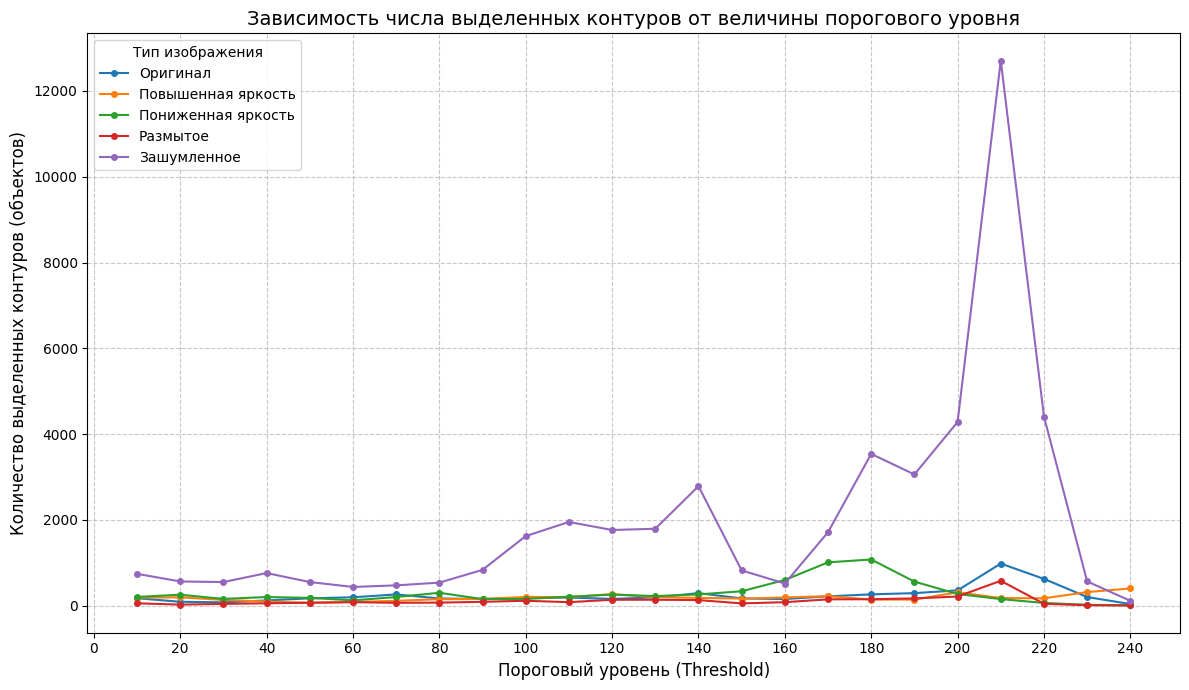

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import deque

# -----------------------------------------------------------------------------
# ЧАСТЬ 1: Вспомогательные функции
# -----------------------------------------------------------------------------

def rgb_to_grayscale(img):
    """
    Преобразует цветное изображение (RGB) в оттенки серого.
    Формула luminance: Y = 0.2989 * R + 0.5870 * G + 0.1140 * B
    Возвращает массив numpy типа float64 со значениями от 0 до 255.
    """
    # Проверяем, если изображение уже ч/б (2 канала или 1 канал), возвращаем как есть
    if len(img.shape) == 2:
        return img.astype(np.float64)

    # Извлекаем каналы
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    # Применяем формулу яркости
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray

def count_contours_simple(binary_img):
    """
    Подсчитывает количество связных областей (контуров/объектов) на бинарном изображении.
    Использует алгоритм поиска в ширину (BFS) для маркировки посещенных пикселей.

    Аргументы:
    binary_img: 2D numpy array, где 255 - объект, 0 - фон.

    Возвращает:
    int: количество найденных связных областей.
    """
    # Создаем копию изображения, чтобы не портить оригинал,
    # и массив для отслеживания посещенных пикселей (True/False)
    visited = np.zeros_like(binary_img, dtype=bool)

    # Получаем размеры изображения
    rows, cols = binary_img.shape

    # Находим координаты всех белых пикселей (объектов)
    # np.where возвращает кортеж массивов (y_coords, x_coords)
    obj_y, obj_x = np.where(binary_img > 127) # 127 как середина диапазона 0-255

    # Если белых пикселей нет, контуров тоже нет
    if len(obj_y) == 0:
        return 0

    contour_count = 0

    # Перебираем все белые пиксели
    for i in range(len(obj_y)):
        y = obj_y[i]
        x = obj_x[i]

        # Если этот пиксель еще не посещен, значит мы нашли новый объект
        if not visited[y, x]:
            contour_count += 1

            # Запускаем "заливку" (BFS), чтобы пометить весь этот объект как посещенный
            queue = deque()
            queue.append((y, x))
            visited[y, x] = True

            while queue:
                cy, cx = queue.popleft()

                # Проверяем 4 соседних пикселя (верх, низ, лево, право)
                neighbors = [
                    (cy - 1, cx), (cy + 1, cx),
                    (cy, cx - 1), (cy, cx + 1)
                ]

                for ny, nx in neighbors:
                    # Проверка границ изображения
                    if 0 <= ny < rows and 0 <= nx < cols:
                        # Если сосед белый и еще не посещен
                        if binary_img[ny, nx] > 127 and not visited[ny, nx]:
                            visited[ny, nx] = True
                            queue.append((ny, nx))

    return contour_count

def process_image_pipeline(image_path, thresholds):
    """
    Полный цикл обработки одного изображения:
    1. Загрузка
    2. Перевод в серый
    3. Для каждого порога: бинаризация -> подсчет контуров

    Возвращает список количеств контуров для каждого порога.
    """
    try:
        # Загрузка изображения через matplotlib
        img = mpimg.imread(image_path)

        # Если изображение имеет альфа-канал (RGBA), обрезаем его
        if img.shape[2] == 4:
            img = img[:, :, :3]

    except Exception as e:
        print(f"Ошибка загрузки {image_path}: {e}")
        return None

    # Перевод в оттенки серого
    gray_img = rgb_to_grayscale(img)

    counts = []

    # Для каждого порогового значения выполняем бинаризацию и подсчет
    for thresh in thresholds:
        # Бинаризация: если пиксель >= порога, то 255, иначе 0
        # Результат - булев массив, приводим к uint8 для наглядности (хотя для функции count важно только > 127)
        binary = (gray_img >= thresh).astype(np.uint8) * 255

        # Подсчет контуров
        n_contours = count_contours_simple(binary)
        counts.append(n_contours)

    return counts

# -----------------------------------------------------------------------------
# ЧАСТЬ 2: Основные настройки и выполнение
# -----------------------------------------------------------------------------

# Список путей к вашим файлам
image_files = [
    'aruco_1_orig.jpg',
    'aruco_2_brighted.jpg',
    'aruco_3_darked.jpg',
    'aruco_4_blured.jpg',
    'aruco_5_noised.jpg'
]

# Названия для легенды графика
image_labels = [
    'Оригинал',
    'Повышенная яркость',
    'Пониженная яркость',
    'Размытое',
    'Зашумленное'
]

# Диапазон пороговых значений.
# ArUco маркеры обычно имеют высокий контраст.
# Берем диапазон от 10 до 240 с шагом 10 для построения гладкого графика.
# Шаг можно увеличить (например, 20), если код выполняется слишком долго.
thresholds = list(range(10, 250, 10))

print("Начинается обработка изображений")

# Словарь для хранения результатов: {имя_изображения: [кол-во_контуров]}
results = {}

for path, label in zip(image_files, image_labels):
    print(f"Обработка: {label} ({path})")
    counts = process_image_pipeline(path, thresholds)
    if counts is not None:
        results[label] = counts
        print(f"  Готово: {label} ({path})")

# -----------------------------------------------------------------------------
# ЧАСТЬ 3: Визуализация результатов
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Построение графика для каждого изображения
for label, counts in results.items():
    plt.plot(thresholds, counts, marker='o', linestyle='-', label=label, markersize=4)

# Оформление графика
plt.title('Зависимость числа выделенных контуров от величины порогового уровня', fontsize=14)
plt.xlabel('Пороговый уровень (Threshold)', fontsize=12)
plt.ylabel('Количество выделенных контуров (объектов)', fontsize=12)
plt.legend(title="Тип изображения", loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(0, 260, 20)) # Шкала по X каждые 20 единиц

# Показать график
plt.tight_layout()
plt.show()

**Влияние качества изображения на число выделенных контуров:**
- Повышение яркости - количество выделенных контуров снизилось, при этом распределение порогового уровня сместилось вправо (больше белых пикселей);
- Понижение яркости - количество выделенных контуров выросло, при этом распределение порогового уровня сместилось влево (больше черных пикселей);
- Размытие - количество выделенных контуров снизилось;
- Шум - количество выделенных контуров резко возросло.

# Шаг 4

***Задание***

*Для изображений п.3 постройте график зависимости числа выделенных маркеров ARUCO от пороговой площади для фильтрации контуров.*

Обработка изображений...
Оригинал...
    Найдено кандидатов всего: 76
Повышенная яркость...
    Найдено кандидатов всего: 148
Пониженная яркость...
    Найдено кандидатов всего: 147
Размытое...
    Найдено кандидатов всего: 54
Зашумленное...
    Найдено кандидатов всего: 1514

 Построение раздельных графиков...


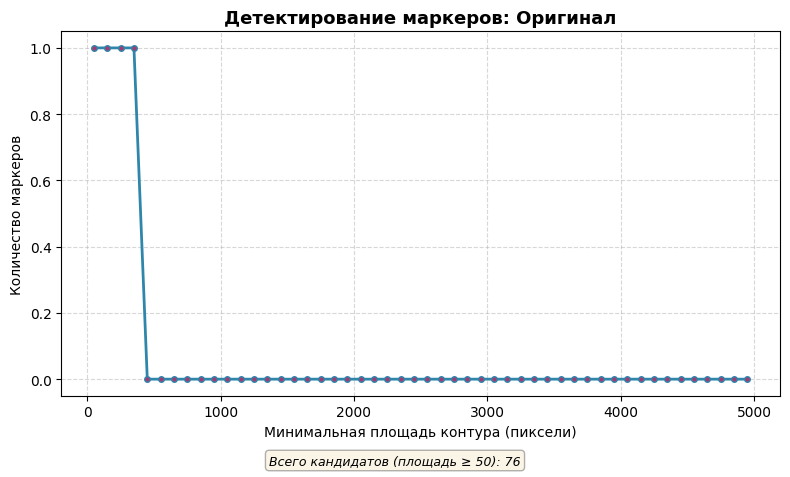

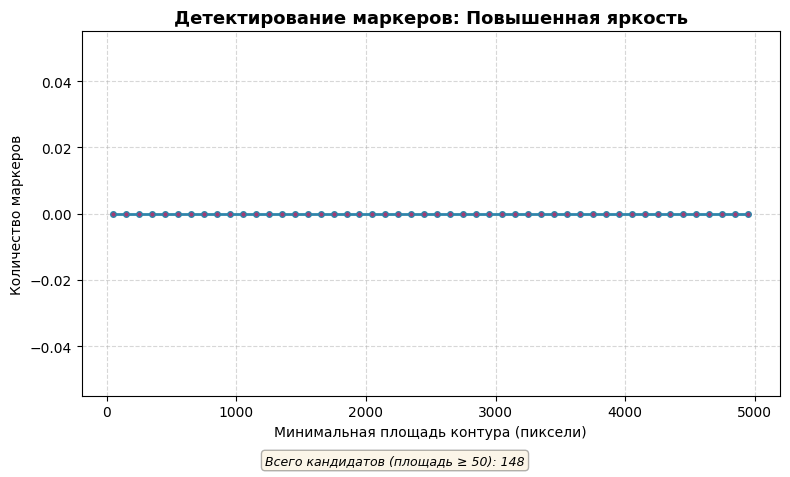

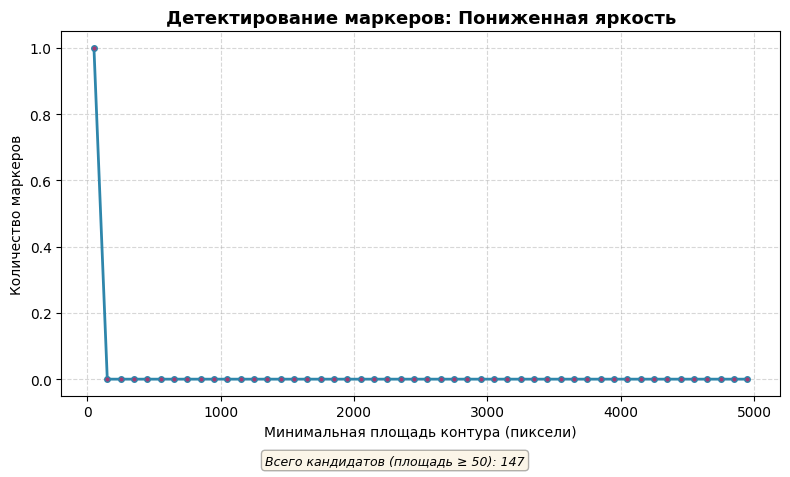

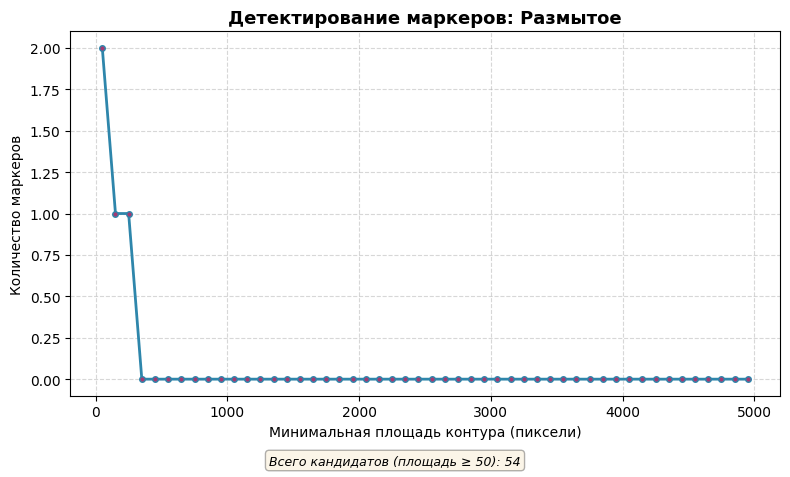

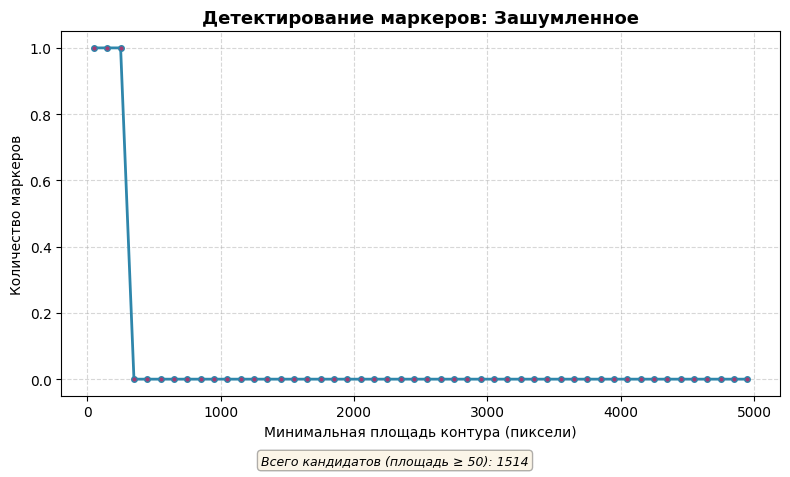


📈 Построение сводного графика для сравнения...


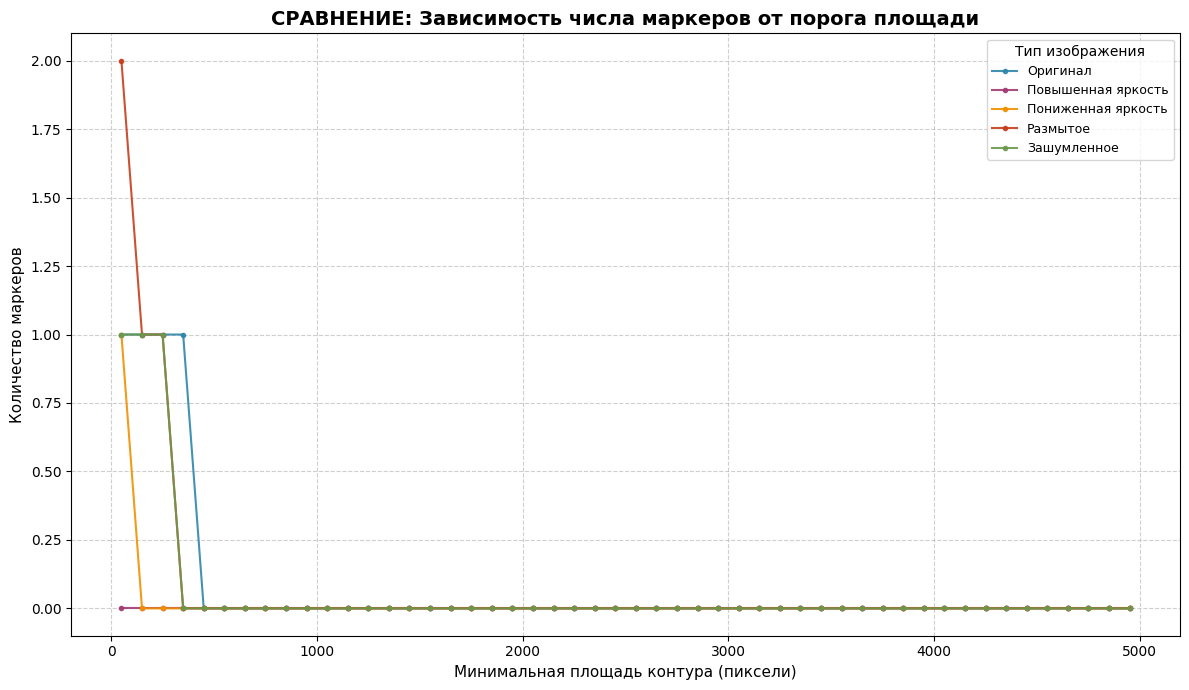


 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Изображение          | Кандидатов всего   | Маркеров при площади ≥500
----------------------------------------------------------------------
Оригинал             | 76                 | 0                        
Повышенная яркость   | 148                | 0                        
Пониженная яркость   | 147                | 0                        
Размытое             | 54                 | 0                        
Зашумленное          | 1514               | 0                        


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import deque

# =============================================================================
# БЛОК 1: ФУНКЦИИ ДЛЯ ПОИСКА И АНАЛИЗА КОНТУРОВ
# =============================================================================

def rgb_to_grayscale(img):
    """Конвертация RGB в оттенки серого (формула люминантности)."""
    if len(img.shape) == 2:
        return img.astype(np.float64)
    if img.shape[2] == 4:
        img = img[:, :, :3]
    r, g, b = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    return 0.2989 * r + 0.5870 * g + 0.1140 * b

def find_contours_with_info(binary_img):
    """
    Находит все связные области (контуры) на бинарном изображении.
    Возвращает список словарей с информацией о каждом контуре.
    """
    visited = np.zeros_like(binary_img, dtype=bool)
    rows, cols = binary_img.shape
    obj_y, obj_x = np.where(binary_img > 127)

    if len(obj_y) == 0:
        return []

    contours_info = []

    for i in range(len(obj_y)):
        y, x = obj_y[i], obj_x[i]
        if visited[y, x]:
            continue

        queue = deque([(y, x)])
        visited[y, x] = True
        pixels = []
        y_min, y_max = y, y
        x_min, x_max = x, x

        while queue:
            cy, cx = queue.popleft()
            pixels.append((cy, cx))
            y_min = min(y_min, cy)
            y_max = max(y_max, cy)
            x_min = min(x_min, cx)
            x_max = max(x_max, cx)

            for ny, nx in [(cy-1,cx), (cy+1,cx), (cy,cx-1), (cy,cx+1)]:
                if (0 <= ny < rows and 0 <= nx < cols and
                    binary_img[ny, nx] > 127 and not visited[ny, nx]):
                    visited[ny, nx] = True
                    queue.append((ny, nx))

        contours_info.append({
            'pixels': pixels,
            'area': len(pixels),
            'bbox': (y_min, y_max, x_min, x_max)
        })

    return contours_info

def check_aruco_like(binary_img, contour_info, min_aspect_ratio=0.5, max_aspect_ratio=2.0):
    """
    Проверяет, похож ли контур на маркер ARUCO по геометрическим признакам.
    """
    y_min, y_max, x_min, x_max = contour_info['bbox']
    height = y_max - y_min + 1
    width = x_max - x_min + 1

    # КРИТЕРИЙ 1: Квадратность формы
    aspect_ratio = width / height if height > 0 else 0
    if not (min_aspect_ratio <= aspect_ratio <= max_aspect_ratio):
        return False

    roi = binary_img[y_min:y_max+1, x_min:x_max+1]

    # КРИТЕРИЙ 2: Однородность периметра (рамка маркера)
    perimeter_pixels = []
    perimeter_pixels.extend(roi[0, :])
    perimeter_pixels.extend(roi[-1, :])
    if roi.shape[0] > 2:
        perimeter_pixels.extend(roi[1:-1, 0])
        perimeter_pixels.extend(roi[1:-1, -1])

    if len(perimeter_pixels) == 0:
        return False

    perimeter_pixels = np.array(perimeter_pixels)
    white_ratio = np.mean(perimeter_pixels > 127)
    if max(white_ratio, 1 - white_ratio) < 0.8:
        return False

    # КРИТЕРИЙ 3: Контраст внутренней области
    if roi.shape[0] < 10 or roi.shape[1] < 10:
        return True

    inner = roi[1:-1, 1:-1] if roi.shape[0] > 2 and roi.shape[1] > 2 else roi
    if inner.size == 0:
        return False

    inner_white = np.sum(inner > 127)
    inner_black = np.sum(inner <= 127)
    total_inner = inner.size

    if total_inner > 0:
        white_inner_ratio = inner_white / total_inner
        if white_inner_ratio < 0.2 or white_inner_ratio > 0.8:
            return False

    return True

def detect_aruco_candidates(gray_img, fixed_threshold=127):
    """Пайплайн детектирования кандидатов в маркеры."""
    binary = (gray_img >= fixed_threshold).astype(np.uint8) * 255
    all_contours = find_contours_with_info(binary)
    aruco_candidates = [c for c in all_contours if check_aruco_like(binary, c)]
    return aruco_candidates

def count_markers_by_area_threshold(image_path, area_thresholds,
                                     fixed_binary_threshold=127):
    """
    Считает количество детектированных маркеров при разных порогах площади.
    """
    try:
        img = mpimg.imread(image_path)
        if img.shape[2] == 4:
            img = img[:, :, :3]
    except Exception as e:
        print(f"Ошибка загрузки {image_path}: {e}")
        return None

    gray = rgb_to_grayscale(img)
    all_candidates = detect_aruco_candidates(gray, fixed_threshold=fixed_binary_threshold)

    results = []
    for min_area in area_thresholds:
        count = sum(1 for c in all_candidates if c['area'] >= min_area)
        results.append(count)

    return results, len(all_candidates)  # Возвращаем также общее число кандидатов

# =============================================================================
# БЛОК 2: НАСТРОЙКИ И ОБРАБОТКА
# =============================================================================

image_files = [
    'aruco_1_orig.jpg',
    'aruco_2_brighted.jpg',
    'aruco_3_darked.jpg',
    'aruco_4_blured.jpg',
    'aruco_5_noised.jpg'
]

image_labels = [
    'Оригинал',
    'Повышенная яркость',
    'Пониженная яркость',
    'Размытое',
    'Зашумленное'
]

# Пороги площади (настройте под размер ваших маркеров!)
area_thresholds = list(range(50, 5000, 100))

# Фиксированный порог бинаризации (подберите оптимальный для ваших изображений)
BINARY_THRESHOLD = 127

print("Обработка изображений...")

results_data = {}  # {label: {'counts': [...], 'total_candidates': int}}

for path, label in zip(image_files, image_labels):
    print(f"{label}...")
    result = count_markers_by_area_threshold(
        path,
        area_thresholds,
        fixed_binary_threshold=BINARY_THRESHOLD
    )
    if result is not None:
        counts, total = result
        results_data[label] = {'counts': counts, 'total_candidates': total}
        print(f"    Найдено кандидатов всего: {total}")

# =============================================================================
# БЛОК 3: РАЗДЕЛЬНЫЕ ГРАФИКИ (по одному на изображение)
# =============================================================================

print("\n Построение раздельных графиков...")

for label, data in results_data.items():
    counts = data['counts']

    # Создаём отдельную фигуру для каждого изображения
    plt.figure(figsize=(8, 5))
    plt.plot(area_thresholds, counts,
             marker='o', linestyle='-', linewidth=2, markersize=4,
             color='#2E86AB', markerfacecolor='#A23B72')

    plt.title(f'Детектирование маркеров: {label}', fontsize=13, fontweight='bold')
    plt.xlabel('Минимальная площадь контура (пиксели)', fontsize=10)
    plt.ylabel('Количество маркеров', fontsize=10)

    # Добавляем сетку для удобства чтения
    plt.grid(True, linestyle='--', alpha=0.5)

    # Подпись с общим числом кандидатов
    plt.figtext(0.5, 0.01, f'Всего кандидатов (площадь ≥ 50): {data["total_candidates"]}',
                ha='center', fontsize=9, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Место для подписи внизу
    plt.show()

# =============================================================================
# БЛОК 4: СВОДНЫЙ ГРАФИК (для сравнения всех изображений)
# =============================================================================

print("\n📈 Построение сводного графика для сравнения...")

plt.figure(figsize=(12, 7))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

for (label, data), color in zip(results_data.items(), colors):
    plt.plot(area_thresholds, data['counts'],
             marker='o', linestyle='-', linewidth=1.5, markersize=3,
             label=label, color=color, alpha=0.9)

plt.title('СРАВНЕНИЕ: Зависимость числа маркеров от порога площади', fontsize=14, fontweight='bold')
plt.xlabel('Минимальная площадь контура (пиксели)', fontsize=11)
plt.ylabel('Количество маркеров', fontsize=11)
plt.legend(title="Тип изображения", loc='upper right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# =============================================================================
# БЛОК 5: СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# =============================================================================

print("\n" + "="*70)
print(" СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)

print(f"{'Изображение':<20} | {'Кандидатов всего':<18} | {'Маркеров при площади ≥500':<25}")
print("-"*70)

for label, data in results_data.items():
    total = data['total_candidates']
    # Находим индекс порога 500 (или ближайший)
    idx_500 = min(range(len(area_thresholds)), key=lambda i: abs(area_thresholds[i] - 500))
    count_500 = data['counts'][idx_500]
    print(f"{label:<20} | {total:<18} | {count_500:<25}")

print("="*70)



***КАК ИНТЕРПРЕТИРОВАТЬ ГРАФИКИ:***

**Формат каждого отдельного графика:**
   - Ось X: минимальная площадь фильтрации (чем больше — тем строже отбор)
   - Ось Y: сколько контуров прошло проверку "похожести на ARUCO"
   - Кривая всегда убывает: при росте порога мелкие объекты отсеиваются

**Что искать на графике:**
   - "Полка" (плато) — диапазон площадей, где количество маркеров стабильно.
     Это и есть вероятный диапазон размеров реальных маркеров на изображении.
   - Резкий спад в начале — много мелкого шума, который отсеивается.
   - Плавный спад — маркеры разного размера или пограничные случаи.

**Сравнение между изображениями (по сводному графику):**
   - Оригинал: эталонная кривая, с которой сравниваем остальные.
   - Яркое/Тёмное: кривая может быть ниже — потеря контраста уменьшает
     число успешно детектированных маркеров.
   - Размытое: кривая может спадать раньше — искажение формы приводит
     к отсеву по критерию квадратности.
   - Зашумленное: кривая начинается выше (много шума), но быстро падает
     — порог площади эффективно удаляет ложные срабатывания.

**Практический вывод:**
   Оптимальный порог площади выбирается в области "плато" кривой.
   Для разных условий съёмки этот порог может отличаться — поэтому
   в реальных системах его часто подбирают адаптивно или калибруют
   на тестовых изображениях.

# Шаг 5

***Задание***

*Выделите все маркеры на каждом изображении.*

In [ ]:
def visualize_detected_markers(image_path, label, binary_thresh=127, min_area=200):
    """
    Визуализирует найденные кандидаты в маркеры на изображении.
    Раскомментируйте вызов этой функции ниже, чтобы включить.
    """
    img = mpimg.imread(image_path)
    if img.shape[2] == 4:
        img = img[:, :, :3]
    gray = rgb_to_grayscale(img)

    candidates = detect_aruco_candidates(gray, fixed_threshold=binary_thresh)
    # Фильтруем по площади для наглядности
    filtered = [c for c in candidates if c['area'] >= min_area]

    plt.figure(figsize=(9, 9))
    plt.imshow(img)
    plt.title(f'{label}\nНайдено маркеров (площадь ≥ {min_area}): {len(filtered)}',
              fontsize=12, fontweight='bold')

    for i, c in enumerate(filtered):
        y_min, y_max, x_min, x_max = c['bbox']
        rect = plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                             linewidth=2, edgecolor='#00FF00', facecolor='none',
                             label='Маркер' if i==0 else "")
        plt.gca().add_patch(rect)
        plt.text(x_min, y_min-8, f"{c['area']}px", color='#00FF00', fontsize=8,
                 bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return len(filtered)

for path, label in zip(image_files, image_labels):
    print(f"\n🖼️  Визуализация: {label}")
    visualize_detected_markers(path, label, binary_thresh=BINARY_THRESHOLD, min_area=200)